# v2a-RSN stability metrics

This notebook loads each c-GC `.pkl` file in `data/v2a-RSN/`, normalizes the adjacency matrices for `P = 1..7`, and computes the ground-truth-free stability metrics:

- `edge_counts`
- `D_p`
- `D_parts` (`D_minus`, `D_plus`)
- `T_obs`

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd

CAUSALISED_GC_RELATIVE_PATH = Path('src/markovianity_diagnostic/core/causalised-GC.py')
PROJECT_ROOT = next(
    (p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
     if (p / CAUSALISED_GC_RELATIVE_PATH).exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        f"Could not find '{CAUSALISED_GC_RELATIVE_PATH}' from {Path.cwd().resolve()}"
    )

SRC_PATH = PROJECT_ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from markovianity_diagnostic.experiments.graph_metrics import compute_graph_stability_metrics

DATA_DIR = PROJECT_ROOT / 'data' / 'v2a-RSN'
OUTPUT_DIR = PROJECT_ROOT / 'data' / 'outputs' / 'v2a_RSN_metrics'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EXPECTED_P_VALUES = list(range(1, 8))

def load_adjacencies(path: Path) -> dict[int, np.ndarray]:
    raw = pd.read_pickle(path)
    if not isinstance(raw, dict):
        raise TypeError(f'{path.name} must contain a dict keyed by P values, got {type(raw)!r}')

    adjacencies: dict[int, np.ndarray] = {}
    for key, value in raw.items():
        adjacency = np.asarray(value).astype(int)
        if adjacency.ndim != 2 or adjacency.shape[0] != adjacency.shape[1]:
            raise ValueError(
                f'{path.name} has invalid adjacency for P={key}: expected square matrix, got {adjacency.shape}'
            )
        adjacency = (adjacency != 0).astype(int)
        np.fill_diagonal(adjacency, 0)
        adjacencies[int(key)] = adjacency

    missing = sorted(set(EXPECTED_P_VALUES).difference(adjacencies))
    if missing:
        raise ValueError(f'{path.name} is missing P values: {missing}')

    return {p: adjacencies[p] for p in EXPECTED_P_VALUES}


def metrics_table(dataset_name: str, path: Path) -> tuple[dict[str, object], pd.DataFrame]:
    adjacencies = load_adjacencies(path)
    metrics = compute_graph_stability_metrics(adjacencies)

    summary = {
        'dataset': dataset_name,
        'file': path.name,
        'n_nodes': int(next(iter(adjacencies.values())).shape[0]),
        'n_p_values': len(adjacencies),
        'T_obs': float(metrics['T_obs']),
        'edge_counts': {int(k): int(v) for k, v in metrics['edge_counts'].items()},
        'D_p': {int(k): float(v) for k, v in metrics['D_p'].items()},
        'D_parts': {
            int(k): {'D_minus': float(v['D_minus']), 'D_plus': float(v['D_plus'])}
            for k, v in metrics['D_parts'].items()
        },
    }

    rows = []
    for p_value in EXPECTED_P_VALUES:
        row = {
            'dataset': dataset_name,
            'file': path.name,
            'P': p_value,
            'edge_count': int(metrics['edge_counts'][p_value]),
        }
        if p_value in metrics['D_p']:
            row['D_p'] = float(metrics['D_p'][p_value])
            row['D_minus'] = float(metrics['D_parts'][p_value]['D_minus'])
            row['D_plus'] = float(metrics['D_parts'][p_value]['D_plus'])
        else:
            row['D_p'] = np.nan
            row['D_minus'] = np.nan
            row['D_plus'] = np.nan
        rows.append(row)

    return summary, pd.DataFrame(rows)

print(f'Project root: {PROJECT_ROOT}')
print(f'Data dir: {DATA_DIR}')
print(f'Output dir: {OUTPUT_DIR}')

Project root: /Users/sadiqadedayo/Documents/projects/Detecting Latent confounders with Markovianity/hidden-confounding-diagnostics
Data dir: /Users/sadiqadedayo/Documents/projects/Detecting Latent confounders with Markovianity/hidden-confounding-diagnostics/data/v2a-RSN
Output dir: /Users/sadiqadedayo/Documents/projects/Detecting Latent confounders with Markovianity/hidden-confounding-diagnostics/data/outputs/v2a_RSN_metrics


In [2]:
pkl_files = sorted(DATA_DIR.glob('*.pkl'))
if len(pkl_files) != 4:
    print(f'Warning: expected 4 pickle files, found {len(pkl_files)}')

dataset_summaries: list[dict[str, object]] = []
transition_frames: list[pd.DataFrame] = []

for path in pkl_files:
    dataset_name = path.stem
    summary, transition_df = metrics_table(dataset_name, path)
    dataset_summaries.append(summary)
    transition_frames.append(transition_df)

summary_df = pd.DataFrame(dataset_summaries).sort_values('dataset').reset_index(drop=True)
transition_df = pd.concat(transition_frames, ignore_index=True).sort_values(['dataset', 'P']).reset_index(drop=True)

summary_df.to_csv(OUTPUT_DIR / 'summary.csv', index=False)
transition_df.to_csv(OUTPUT_DIR / 'transitions.csv', index=False)

serializable = [
    {
        'dataset': row['dataset'],
        'file': row['file'],
        'n_nodes': row['n_nodes'],
        'n_p_values': row['n_p_values'],
        'T_obs': row['T_obs'],
        'edge_counts': row['edge_counts'],
        'D_p': row['D_p'],
        'D_parts': row['D_parts'],
    }
    for row in dataset_summaries
]
with open(OUTPUT_DIR / 'summary.json', 'w', encoding='utf-8') as f:
    json.dump(serializable, f, indent=2)

summary_df

,dataset,file,n_nodes,n_p_values,T_obs,edge_counts,D_p,D_parts
0,220119_F2_run11,220119_F2_run11.pkl,100,7,0.025859,"{1: 477, 2: 315, 3: 270, 4: 253, 5: 259, 6: 26...","{2: 0.02585858585858586, 3: 0.0134343434343434...","{2: {'D_minus': 0.021111111111111112, 'D_plus'..."
1,220127_F4_run2,220127_F4_run2.pkl,92,7,0.033684,"{1: 487, 2: 421, 3: 411, 4: 376, 5: 373, 6: 38...","{2: 0.03368370759675107, 3: 0.0191113234591495...","{2: {'D_minus': 0.020783564261825132, 'D_plus'..."
2,220210_F1_run6,220210_F1_run6.pkl,130,7,0.056887,"{1: 1232, 2: 710, 3: 631, 4: 655, 5: 661, 6: 7...","{2: 0.05688729874776386, 3: 0.0236732259988073...","{2: {'D_minus': 0.04400715563506261, 'D_plus':..."
3,220210_F2_run5,220210_F2_run5.pkl,165,7,0.028381,"{1: 1034, 2: 826, 3: 804, 4: 823, 5: 849, 6: 8...","{2: 0.028381374722838137, 3: 0.013747228381374...","{2: {'D_minus': 0.0180339985218034, 'D_plus': ..."


In [3]:
summary_df[['dataset', 'file', 'n_nodes', 'n_p_values', 'T_obs']]

,dataset,file,n_nodes,n_p_values,T_obs
0,220119_F2_run11,220119_F2_run11.pkl,100,7,0.025859
1,220127_F4_run2,220127_F4_run2.pkl,92,7,0.033684
2,220210_F1_run6,220210_F1_run6.pkl,130,7,0.056887
3,220210_F2_run5,220210_F2_run5.pkl,165,7,0.028381


In [ ]:
transition_df

## Saved outputs

The notebook writes the aggregated metrics to:

- `data/outputs/v2a_RSN_metrics/summary.csv`
- `data/outputs/v2a_RSN_metrics/transitions.csv`
- `data/outputs/v2a_RSN_metrics/summary.json`

Saved plot to: /Users/sadiqadedayo/Documents/projects/Detecting Latent confounders with Markovianity/hidden-confounding-diagnostics/data/outputs/v2a_RSN_metrics/npasts_links.png


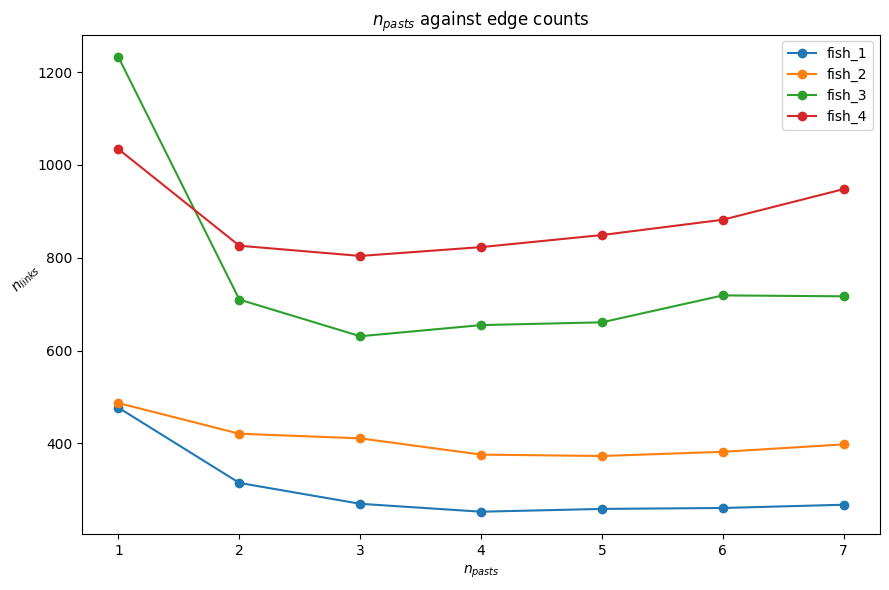

: 

In [ ]:
# Plot edge_counts vs n_pasts for each dataset (replicate attached image, no grid)
import pandas as pd
import matplotlib.pyplot as plt

OUT_DIR = PROJECT_ROOT / 'data' / 'outputs' / 'v2a_RSN_metrics'
df = pd.read_csv(OUT_DIR / 'transitions.csv')

pivot = df.pivot(index='P', columns='dataset', values='edge_count').sort_index()

# Map datasets to fish_1..4 labels in order
datasets = list(pivot.columns)
labels = {datasets[i]: f'fish_{i+1}' for i in range(len(datasets))}
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
markers = ['o', 'o', 'o', 'o']

fig, ax = plt.subplots(figsize=(9, 6))
for i, ds in enumerate(datasets):
    ax.plot(pivot.index, pivot[ds], marker=markers[i], color=colors[i], label=labels[ds])

ax.set_xlabel('$n_{pasts}$')
ax.set_ylabel('$n_{links}$', rotation=45)
ax.set_title('$n_{pasts}$ against edge counts')
ax.set_xticks(pivot.index.tolist())
ax.legend()
ax.grid(False)
plt.tight_layout()

out_path = OUT_DIR / 'npasts_links.png'
fig.savefig(out_path, dpi=200)
print(f'Saved plot to: {out_path}')
plt.show()